In [19]:
import sys

print(sys.executable)

c:\Users\arifu\miniforge3\envs\main-ml\python.exe


In [20]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import seaborn
from prophet import Prophet
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd


s1 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2009-2010')
s2 = pd.read_excel('online_retail_II.xlsx', sheet_name='Year 2010-2011')
df = pd.concat([s1, s2], ignore_index=True)


df = df.rename(columns={'Invoice': 'InvoiceNo', 'Price': 'UnitPrice', 'Customer ID': 'CustomerID'})

df = df.dropna(subset=['Description'])                  
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]     

df['Description'] = df['Description'].str.strip()

exclude = ['DOTCOM POSTAGE','POSTAGE','Manual','CARRIAGE','BANK CHARGES',
           'SAMPLES','AMAZON FEE','CRUK Commission','Adjust bad debt']
df = df[~df['Description'].isin(exclude)]

df['Sales'] = df['Quantity'] * df['UnitPrice']

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Week'] = df['InvoiceDate'].dt.to_period('W').apply(lambda r: r.start_time.date())


weekly_total_sales_2yr = (
    df.groupby('Week', as_index=False)['Sales']
      .sum()
      .sort_values('Week')
)

weekly_total_sales_2yr.to_csv('weekly_total_sales_2yr.csv', index=False)

TypeError: Series.sort_values() takes 1 positional argument but 2 were given

In [ ]:
top15 = (df.groupby('Description')['Sales']
           .sum()
           .sort_values(ascending=False)
           .head(15)
           .index
           .tolist())

d = df[df['Description'].isin(top15)].copy()

weekly_top15 = (d.groupby(['Week', 'Description'])
                  .agg(
                      Quantity=('Quantity', 'sum'),
                      Sales=('Sales', 'sum'),
                      AvgUnitPrice=('UnitPrice', 'mean'),
                      Orders=('InvoiceNo', 'nunique')
                  )
                  .sort_values(['Description', 'Week'])
                  .reset_index())

weekly_top15.to_csv('weekly_top15_products_2yr.csv', index=False)


In [ ]:
df = pd.read_csv('weekly_top15_products_2yr.csv')

df.head()

,Week,Description,Quantity,Sales,AvgUnitPrice,Orders
0,2009-11-30,ASSORTED COLOUR BIRD ORNAMENT,2023,3160.37,2.233953,41
1,2009-12-07,ASSORTED COLOUR BIRD ORNAMENT,1213,2046.22,4.192414,29
2,2009-12-14,ASSORTED COLOUR BIRD ORNAMENT,1324,2230.06,4.612424,33
3,2009-12-21,ASSORTED COLOUR BIRD ORNAMENT,82,187.28,7.777500,4
4,2010-01-04,ASSORTED COLOUR BIRD ORNAMENT,168,283.92,1.690000,9


Weekly trend slope: £842/week
Projected range in 17 weeks: £237,713 to £251,191


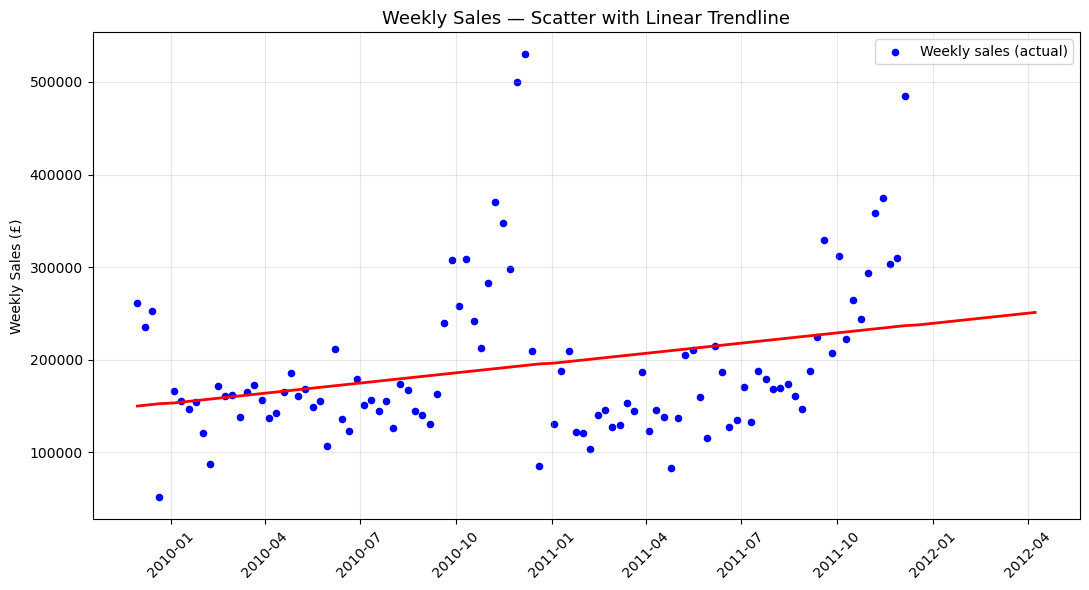

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('weekly_total_sales_2yr.csv', parse_dates=['Week'])
df = df.sort_values('Week')

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df = df.dropna(subset=['Sales'])

df['WeekNum'] = np.arange(len(df))

slope, intercept = np.polyfit(df['WeekNum'], df['Sales'], 1)
trendline = slope * df['WeekNum'] + intercept

extra_weeks = 17

future_weeknum = np.arange(len(df), len(df) + extra_weeks)
future_dates = pd.date_range(
    start=df['Week'].iloc[-1] + pd.Timedelta(weeks=1),
    periods=extra_weeks,
    freq='W'
)

future_trend = slope * future_weeknum + intercept

combined_dates = pd.DatetimeIndex(list(df['Week']) + list(future_dates))
combined_trend = np.concatenate([trendline, future_trend])

print(f"Weekly trend slope: £{slope:,.0f}/week")
print(f"Projected range in {extra_weeks} weeks: £{future_trend[0]:,.0f} to £{future_trend[-1]:,.0f}")

fig, ax = plt.subplots(figsize=(11, 6))

ax.scatter(df['Week'], df['Sales'], s=20, label='Weekly sales (actual)', color='blue')

ax.plot(
    combined_dates,
    combined_trend,
    linewidth=2,
    color='red',
)

ax.set_title('Weekly Sales — Scatter with Linear Trendline', fontsize=13)
ax.set_ylabel('Weekly Sales (£)')
ax.legend()
ax.grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('scatter_trendline_extrapolated.png', dpi=150)
plt.show()

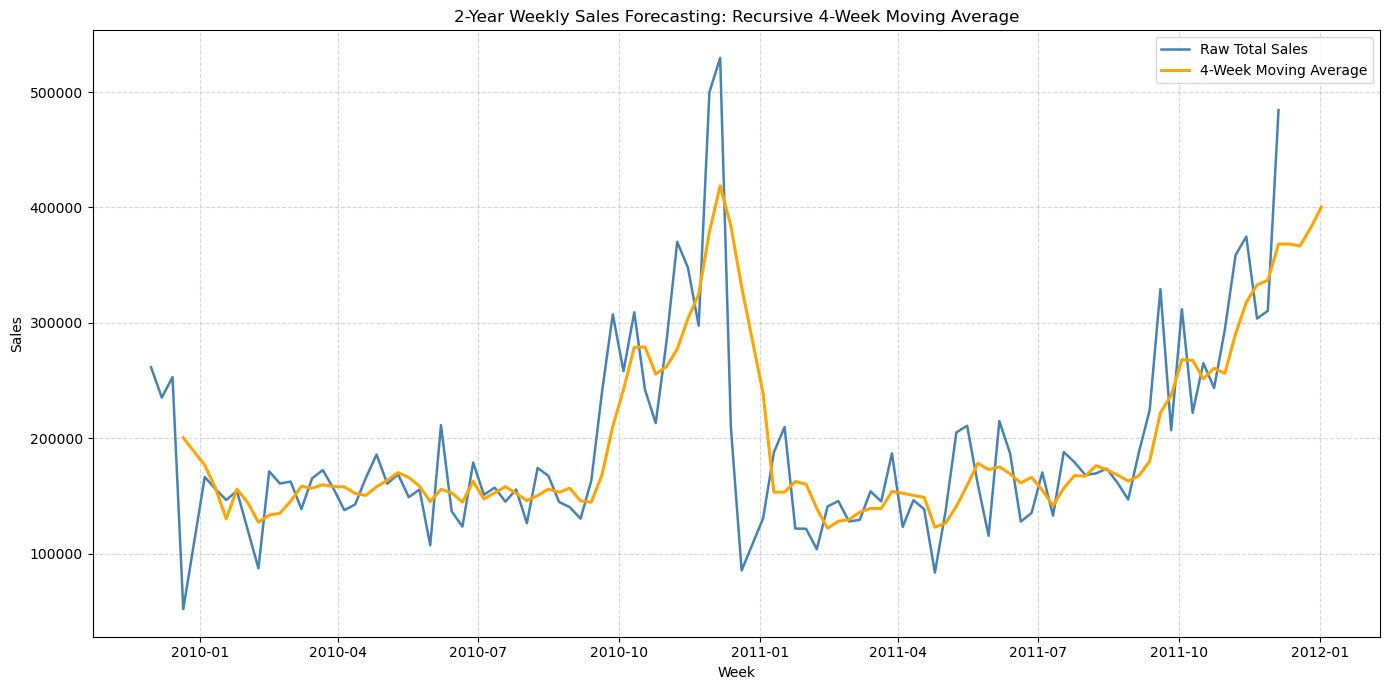

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("weekly_total_sales_2yr.csv")
df["Week"] = pd.to_datetime(df["Week"])
df = df.sort_values("Week")

df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df = df.dropna(subset=["Sales"])

df["MA4"] = df["Sales"].rolling(window=4, min_periods=4).mean()

forecast_weeks = 4
forecast_steps = []

history = df["Sales"].tolist()
last_date = df["Week"].iloc[-1]

for i in range(1, forecast_weeks + 1):
    forecast_value = np.mean(history[-4:])
    forecast_date = last_date + pd.Timedelta(weeks=i)

    forecast_steps.append({
        "Week": forecast_date,
        "Forecast": forecast_value
    })

    history.append(forecast_value)

forecast_df = pd.DataFrame(forecast_steps)

ma4_dates = df["Week"].dropna()
ma4_values = df["MA4"].dropna()

combined_dates = pd.DatetimeIndex(list(ma4_dates) + list(forecast_df["Week"]))
combined_ma = np.concatenate([ma4_values.to_numpy(), forecast_df["Forecast"].to_numpy()])

plt.figure(figsize=(14, 7))

plt.plot(
    df["Week"],
    df["Sales"],
    label="Raw Total Sales",
    color="steelblue",
    linewidth=1.8
)

ma4_dates = df.loc[df["MA4"].notna(), "Week"]
ma4_values = df["MA4"].dropna()

combined_dates = pd.DatetimeIndex(list(ma4_dates) + list(forecast_df["Week"]))
combined_ma = np.concatenate([ma4_values.to_numpy(), forecast_df["Forecast"].to_numpy()])

plt.plot(
    combined_dates,
    combined_ma,
    label="4-Week Moving Average",
    color="orange",
    linewidth=2.2
)

plt.title("2-Year Weekly Sales Forecasting: Recursive 4-Week Moving Average")
plt.xlabel("Week")
plt.ylabel("Sales")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

20:13:23 - cmdstanpy - INFO - Chain [1] start processing
20:13:23 - cmdstanpy - INFO - Chain [1] done processing


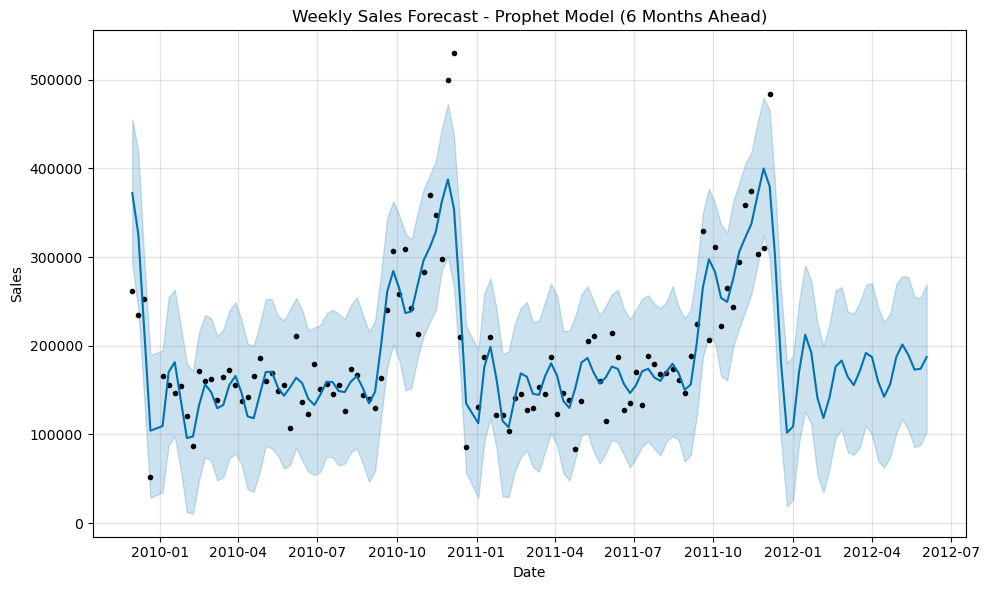

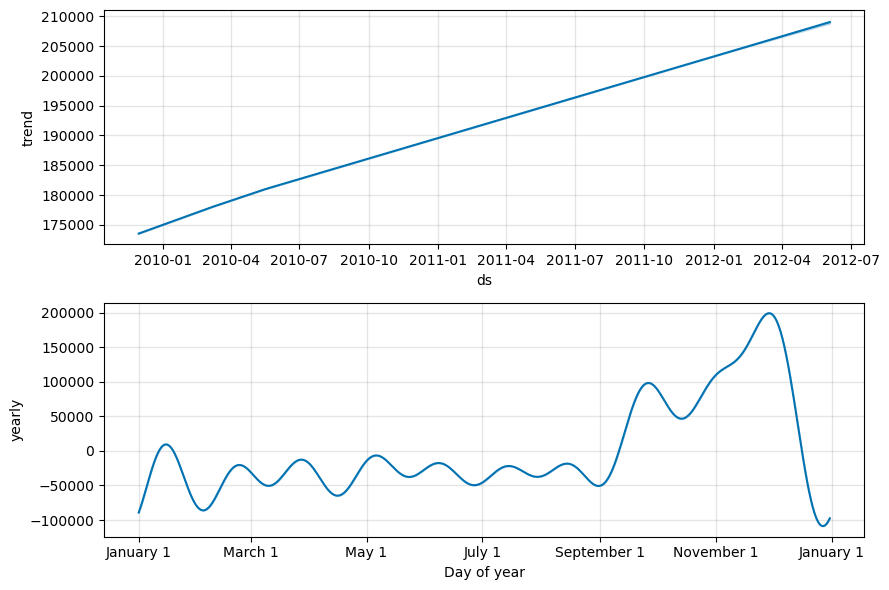

In [ ]:
df = pd.read_csv("weekly_total_sales_2yr.csv")

df["Week"] = pd.to_datetime(df["Week"])

df = df.sort_values("Week")
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
df = df.dropna(subset=["Sales"])

prophet_df = pd.DataFrame({
    "ds": df["Week"],
    "y": df["Sales"]
})

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    seasonality_mode="additive",
    interval_width=0.95
)

model.fit(prophet_df)

forecast_periods = 26

future = model.make_future_dataframe(
    periods=forecast_periods,
    freq="W"
)

forecast = model.predict(future)

fig = model.plot(forecast)
plt.title("Weekly Sales Forecast - Prophet Model (6 Months Ahead)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

fig2 = model.plot_components(forecast)
plt.tight_layout()
plt.show()


In [ ]:
df = pd.read_csv('weekly_total_sales_2yr.csv', parse_dates=['Week'])
df = df.sort_values('Week')

HORIZON = 12

train = df.iloc[:-HORIZON].copy()
test = df.iloc[-HORIZON:].copy()
actual = test['Sales'].values

train['WeekNum'] = np.arange(len(train))
slope, intercept = np.polyfit(train['WeekNum'], train['Sales'], 1)
future_weeknum = np.arange(len(train), len(train) + HORIZON)
trend_forecast = slope * future_weeknum + intercept

moving_history = train['Sales'].tolist()
ma_forecast = []
for _ in range(HORIZON):
    forecast_value = np.mean(moving_history[-4:])
    ma_forecast.append(forecast_value)
    moving_history.append(forecast_value)
ma_forecast = np.array(ma_forecast)

prophet_train = train.rename(columns={'Week': 'ds', 'Sales': 'y'})[['ds', 'y']]
model = Prophet(yearly_seasonality=True, weekly_seasonality=True,
                 seasonality_mode='additive', interval_width=0.95)
model.fit(prophet_train)
future = model.make_future_dataframe(periods=HORIZON, freq='W')
forecast = model.predict(future)
prophet_forecast = forecast.tail(HORIZON)['yhat'].values

def mae_mape(actual, pred):
    mae = np.mean(np.abs(actual - pred))
    mape = np.mean(np.abs((actual - pred) / actual)) * 100
    return mae, mape

results = pd.DataFrame({
    'Week': test['Week'].values,
    'Actual': actual,
    'Trendline': trend_forecast.round(0),
    'MovingAvg': ma_forecast.round(0),
    'Prophet': prophet_forecast.round(0)
})
print(results)

for name, pred in [('Trendline', trend_forecast), ('MovingAvg', ma_forecast), ('Prophet', prophet_forecast)]:
    mae, mape = mae_mape(actual, pred)
    print('{}'.format(name).ljust(10) + " MAE: " + str(round(mae)) + " MAPE: " + str(round(mape,1)) + "%")

results.to_csv('three_way_comparison.csv', index=False)


20:13:24 - cmdstanpy - INFO - Chain [1] start processing
20:13:24 - cmdstanpy - INFO - Chain [1] done processing


         Week      Actual  Trendline  MovingAvg   Prophet
0  2011-09-19  329191.141   182203.0   180130.0   65557.0
1  2011-09-26  206879.251   182284.0   180130.0  111443.0
2  2011-10-03  311850.760   182364.0   180130.0  116493.0
3  2011-10-10  222007.210   182445.0   180130.0   94902.0
4  2011-10-17  265059.280   182525.0   180130.0   79190.0
5  2011-10-24  243566.290   182606.0   180130.0   84860.0
6  2011-10-31  294049.210   182686.0   180130.0  103155.0
7  2011-11-07  358755.370   182767.0   180130.0  124755.0
8  2011-11-14  374736.150   182847.0   180130.0  155547.0
9  2011-11-21  303690.320   182928.0   180130.0  198745.0
10 2011-11-28  310368.860   183008.0   180130.0  228895.0
11 2011-12-05  484290.640   183089.0   180130.0  202482.0
Trendline  MAE:    126,058   MAPE:  37.8%
MovingAvg  MAE:    128,574   MAPE:  38.6%
Prophet    MAE:    178,202   MAPE:  57.4%


We hid the last 12 weeks of real sales, had all three methods predict them blind using only earlier data, then compared each prediction to what actually happened.

MAE (Mean Absolute Error): "On average, our forecast was off by this many pounds, regardless of direction."
MAPE (Mean Absolute Percentage Error): "On average, our forecast was off by this percentage of the actual sales figure."


In [ ]:
df = pd.read_csv('weekly_top15_products_2yr.csv', parse_dates=['Week'])

ranking = (df.groupby('Description')['Sales']
             .sum()
             .sort_values(ascending=False)
             .reset_index(name='Sales'))
print(ranking.head())

best_product_name = ranking.loc[0, 'Description']

p = df[df['Description'] == best_product_name].sort_values('Week')


Description
REGENCY CAKESTAND 3 TIER              344563.25
WHITE HANGING HEART T-LIGHT HOLDER    266923.55
PAPER CRAFT , LITTLE BIRDIE           168469.60
JUMBO BAG RED RETROSPOT               150935.56
PARTY BUNTING                         149187.05
Name: Sales, dtype: float64
